In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

In [15]:
# --- 1. CATBOOST WRAPPER (Để chạy êm ru không lỗi) ---
class CatBoostWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, iterations=200, verbose=0, random_state=42):
        self.iterations = iterations
        self.verbose = verbose
        self.random_state = random_state
        self.model = None
    def fit(self, X, y):
        self.model = CatBoostClassifier(iterations=self.iterations, verbose=self.verbose, 
                                        random_state=self.random_state, allow_writing_files=False)
        self.model.fit(X, y)
        self.classes_ = self.model.classes_ 
        return self
    def predict(self, X): return self.model.predict(X)
    def predict_proba(self, X): return self.model.predict_proba(X)
file_path = 'eye_tracking_features_k30_graph.csv'
df = pd.read_csv(file_path)

In [16]:
X = df.drop(columns=['label', 'numeric_id'])
y = df['label']
print(f"Dữ liệu gốc: {X.shape} đặc trưng)")
#  LỌC ĐẶC TRƯNG (FEATURE SELECTION) 
print("ĐANG LỌC BỎ NHIỄU (FEATURE SELECTION)")
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="mean")
X_selected = selector.fit_transform(X, y)

print(f"=> Đã giảm xuống còn: {X_selected.shape[1]} đặc trưng.")

#  CHUẨN HÓA DỮ LIỆU 
scaler = StandardScaler()
X_final = scaler.fit_transform(X_selected)

Dữ liệu gốc: (160, 908) đặc trưng)
ĐANG LỌC BỎ NHIỄU (FEATURE SELECTION)
=> Đã giảm xuống còn: 313 đặc trưng.


In [17]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ('KNN (k=5)', KNeighborsClassifier(n_neighbors=5)),
    ('SVM (RBF)', SVC(kernel='rbf', probability=True)),
    ('SVM (Linear)', SVC(kernel='linear', probability=True)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ('Extra Trees', ExtraTreesClassifier(n_estimators=200, random_state=42)),
    ('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=42)),
    ('XGBoost', XGBClassifier(n_estimators=200, eval_metric='logloss', use_label_encoder=False, random_state=42)),
    ('LightGBM', LGBMClassifier(n_estimators=200, verbose=-1, random_state=42)),
    ('CatBoost', CatBoostWrapper(iterations=200, verbose=0, random_state=42)),
    ('Neural Net (MLP)', MLPClassifier(max_iter=1000, random_state=42)),
    ('LDA', LinearDiscriminantAnalysis()),
    ('Gaussian Process', GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42))
]

# Voting Ensemble
voting_clf = VotingClassifier(estimators=[
    ('gb', models[5][1]), ('et', models[6][1]), ('svm', models[2][1])], voting='soft')
models.append(('Voting Ensemble', voting_clf))
#  5-FOLD CROSS VALIDATION CHO TẤT CẢ 
print("\n5-FOLD CROSS VALIDATION")
print(f"{'MÔ HÌNH':<25} | {'ACCURACY (TB)':<15} | {'ĐỘ ỔN ĐỊNH (+/-)'}")
print("-" * 65)

results = []
names = []
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models:
    try:
        cv_scores = cross_val_score(model, X_final, y, cv=kfold, scoring='accuracy')
        
        acc_mean = cv_scores.mean() * 100
        acc_std = cv_scores.std() * 100
        
        results.append(acc_mean)
        names.append(name)
        
        print(f"{name:<25} | {acc_mean:.2f}%          | +/- {acc_std:.2f}%")
    except Exception as e:
        print(f"{name:<25} | LỖI: {e}")
        results.append(0)
        names.append(name)


5-FOLD CROSS VALIDATION
MÔ HÌNH                   | ACCURACY (TB)   | ĐỘ ỔN ĐỊNH (+/-)
-----------------------------------------------------------------
Logistic Regression       | 78.75%          | +/- 2.34%
KNN (k=5)                 | 69.38%          | +/- 9.96%
SVM (RBF)                 | 77.50%          | +/- 4.59%
SVM (Linear)              | 73.75%          | +/- 3.19%
Random Forest             | 76.25%          | +/- 6.43%
Gradient Boosting         | 76.25%          | +/- 4.24%
Extra Trees               | 76.25%          | +/- 6.73%
AdaBoost                  | 72.50%          | +/- 3.06%
XGBoost                   | 74.38%          | +/- 3.64%
LightGBM                  | 73.75%          | +/- 5.80%
CatBoost                  | 76.25%          | +/- 5.45%
Neural Net (MLP)          | 80.00%          | +/- 4.24%
LDA                       | 66.88%          | +/- 4.24%
Gaussian Process          | 70.62%          | +/- 7.29%
Voting Ensemble           | 77.50%          | +/- 3.64%


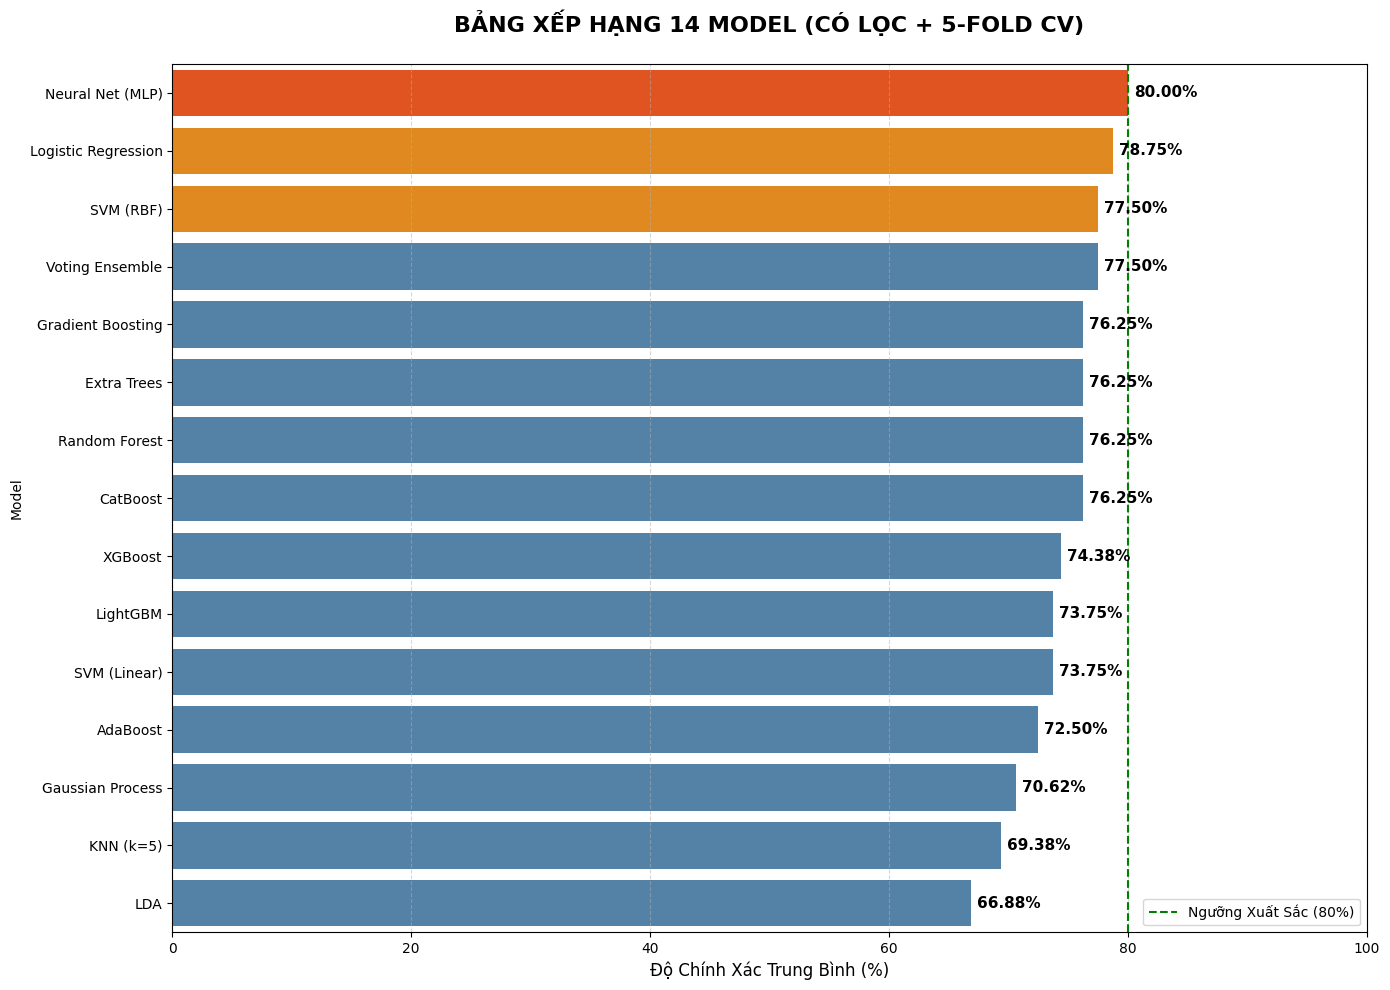


Highest accuracy model: Neural Net (MLP) (80.00%)


In [18]:
# --- 7. VẼ BIỂU ĐỒ ---
df_res = pd.DataFrame({'Model': names, 'Accuracy': results})
df_res = df_res.sort_values(by='Accuracy', ascending=False)
df_res = df_res[df_res['Accuracy'] > 0]

plt.figure(figsize=(14, 10))
# Tô màu: Top 1 Đỏ, Top 2-3 Cam, còn lại Xanh
colors = ['#FF4500' if i==0 else '#FF8C00' if i<3 else '#4682B4' for i in range(len(df_res))]

ax = sns.barplot(x='Accuracy', y='Model', data=df_res, palette=colors)

for i, v in enumerate(df_res['Accuracy']):
    ax.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold', fontsize=11)

plt.title('BẢNG XẾP HẠNG 14 MODEL (CÓ LỌC + 5-FOLD CV)\n', fontsize=16, fontweight='bold')
plt.xlabel('Độ Chính Xác Trung Bình (%)', fontsize=12)
plt.xlim(0, 100)
plt.axvline(x=80, color='green', linestyle='--', label='Ngưỡng Xuất Sắc (80%)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
if not df_res.empty:
    print(f"\nHighest accuracy model: {df_res.iloc[0]['Model']} ({df_res.iloc[0]['Accuracy']:.2f}%)")